# Студенческий workbook. Линейная регрессия vs логистическая регрессия

Этот ноутбук повторяет маршрут основного занятия, но в нем больше мест для ваших гипотез, промежуточных выводов и собственных экспериментов.

## Как работать

1. Сначала пишем гипотезу словами.
2. Потом решаем, чем проверять: графиком, таблицей, метрикой.
3. Только после этого запускаем код.
4. В конце обязательно пишем вывод человеческим языком.

## За что можно получить баллы

- `1 балл` за осмысленную гипотезу.
- `1 балл` за связь гипотезы с EDA.
- `1 балл` за корректную проверку.
- `1 балл` за рабочее улучшение модели.
- `+1 балл`, если вы объяснили, почему идея должна была помочь именно этой модели.

In [76]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")

In [77]:
# из-за квадратов сильно наказываются выбросы, сложно интерпретировать (просто непонятно как оценить, норм или не норм, из-за квадрата)
def mse_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


# мягче к выбросам и к ошибкам в целом (не штрафуется квадратом)
def mae_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


# сохраняет свойство наказания за выбросы, но легче интерпретировать
def rmse_manual(y_true, y_pred):
    return mse_manual(y_true, y_pred) ** 0.5


# отношение разности сумм квадратов в общем и ошибок
def r2_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot else 0.0


# процент отклонения от реальных данных
def mape_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    rmse = rmse_manual(y_true, y_pred)
    std_y = np.std(np.asarray(y_true, dtype=float))
    return {
        "R2": r2_manual(y_true, y_pred),
        "MAE": mae_manual(y_true, y_pred),
        "RMSE": rmse,
        "NRMSE": rmse / std_y if std_y else np.nan,
        "MAPE_%": mape_manual(y_true, y_pred),
    }


# точность - доля правильных ответов. accurancy=(tp+tn)/(tp+tn+ft+fn).
# "если будет дисбаланс классов, один класс будет больше влиять на метрику, чем другой. приоритет - качество определения"
def accuracy_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    return np.mean(y_true == pred)


# корректность - соотношение правильно угаданных среди.
# "он за то, чтобы мы не определяли негативный класс как положительный. приоритет - количество определённых"
def precision_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    tp = np.sum((y_true == 1) & (pred == 1))
    fp = np.sum((y_true == 0) & (pred == 1))
    return tp / (tp + fp) if (tp + fp) else 0.0


# полнота - отношение предсказанных tp из всех РЕАЛЬНЫХ true.
# "про то, чтобы определять его как положительный"
def recall_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    tp = np.sum((y_true == 1) & (pred == 1))
    fn = np.sum((y_true == 1) & (pred == 0))
    return tp / (tp + fn) if (tp + fn) else 0.0


# среднее гармоническое между precision и recall. в отличие от обычного среднего, оно сильно наказывает модель, если одна из метрик близка к нулю. используется, когда важно и не пропускать объекты, и не ошибаться в прогнозах.
# "при 0.5 случайно угаданное. если ниже, нужно проверить инверсию. если больше, видимо, модель чему-то научилась"
def f1_manual(y_true, pred):
    precision = precision_manual(y_true, pred)
    recall = recall_manual(y_true, pred)
    return (
        2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    )


# здесь могла быть реализация Fb = (1 + b^2) * precision * recall / (precision + recall)
# b - вес полноты по отношению к корректности (точности)
# обобщенный для f1 (b=1)
#
# b>1: больший вес придается полноте (recall). модель сильнее наказывается за пропуск FN, чем FP.
# пример: важно найти все случаи болезни, даже если некоторые из них окажутся ложными (диагностика заболеваний)
#
# b<1: больший вес придается точности (precision). модель сильнее наказывается за пропуск FP, чем FN.
# пример: важно не ошибиться при определении положительного класса (спам-фильтр, где важно не поместить важное письмо в спам)


# наказывает модель, если она уверенно ошиблась
def logloss_manual(y_true, prob):
    y_true = np.asarray(y_true, dtype=float)
    prob = np.clip(np.asarray(prob, dtype=float), 1e-6, 1 - 1e-6)
    return -np.mean(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))


def classification_metrics(y_true, prob, pred):
    prob = np.clip(np.asarray(prob, dtype=float), 1e-6, 1 - 1e-6)
    pred = np.asarray(pred, dtype=int)
    return {
        "Accuracy": accuracy_manual(y_true, pred),
        "Precision": precision_manual(y_true, pred),
        "Recall": recall_manual(y_true, pred),
        "F1": f1_manual(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, prob),
        "LogLoss": logloss_manual(y_true, prob),
    }


# заполняет трейн и тест медианами
def fill_missing_from_train(X_train, X_test):
    if isinstance(X_train, pd.DataFrame):
        X_train_filled = X_train.copy()
        X_test_filled = X_test.copy()
        numeric_cols = X_train_filled.select_dtypes(include=[np.number]).columns
        medians = X_train_filled[numeric_cols].median()
        X_train_filled[numeric_cols] = X_train_filled[numeric_cols].fillna(medians)
        X_test_filled[numeric_cols] = X_test_filled[numeric_cols].fillna(medians)
        return X_train_filled, X_test_filled

    X_train_filled = np.asarray(X_train).copy()
    X_test_filled = np.asarray(X_test).copy()
    medians = np.nanmedian(X_train_filled, axis=0)
    train_nan = np.where(np.isnan(X_train_filled))
    test_nan = np.where(np.isnan(X_test_filled))
    if len(train_nan[0]) > 0:
        X_train_filled[train_nan] = np.take(medians, train_nan[1])
    if len(test_nan[0]) > 0:
        X_test_filled[test_nan] = np.take(medians, test_nan[1])
    return X_train_filled, X_test_filled


# преобразует массивы данных в матрицы
def to_numpy_2d(X):
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy(dtype=float)
    elif isinstance(X, pd.Series):
        X = X.to_frame().to_numpy(dtype=float)
    else:
        X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X


# создаёт столбец единиц, чтобы модель дополнительно вычислила w0
def add_bias(X):
    X_arr = to_numpy_2d(X)
    return np.column_stack([np.ones(len(X_arr)), X_arr])


# формула для линейной регрессии
def manual_linear_weights(X_train, y_train):
    Xb = add_bias(X_train)
    y_arr = np.asarray(y_train, dtype=float)
    return np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y_arr


# предсказываем по весам
def manual_linear_predict(X, weights):
    return add_bias(X) @ weights


# стандартизация данных. теперь они одного масштаба (среднее - 0, отклонение - 1)
def standardize_train_test(X_train, X_test):
    X_train_arr = to_numpy_2d(X_train)
    X_test_arr = to_numpy_2d(X_test)
    mean = X_train_arr.mean(axis=0)
    std = X_train_arr.std(axis=0)
    std[std == 0] = 1.0
    return (X_train_arr - mean) / std, (X_test_arr - mean) / std, mean, std


def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1 / (1 + np.exp(-z))


# сама функция обучения модели, котора steps раз пытается уменьшить ошибку модели
def fit_logistic_manual(X_train, y_train, lr=0.2, steps=1200):
    Xb = add_bias(X_train)
    y_arr = np.asarray(y_train, dtype=float)
    weights = np.zeros(Xb.shape[1], dtype=float)
    history = []
    for step in range(steps):
        prob = sigmoid(Xb @ weights)
        grad = Xb.T @ (prob - y_arr) / len(y_arr)
        weights -= lr * grad
        if step % 100 == 0 or step == steps - 1:
            history.append(logloss_manual(y_arr, prob))
    return weights, history


# предсказание
def predict_logistic_manual(X, weights):
    return sigmoid(add_bias(X) @ weights)

## Блок 2. Airbnb: делаем учебно-грязную версию

Теперь переходим к более хаотичному датасету.

### Что важно увидеть заранее

- здесь есть текстовые поля;
- есть география;
- есть категориальные признаки;
- есть пропуски;
- есть экстремальные значения.

То есть тут EDA и чистка будут намного важнее.

In [78]:
airbnb_raw = pd.read_csv("data/AB_NYC_2019.csv")


def make_airbnb_dirty(df):
    data = df.copy()
    base_price = data["price"].astype(int).astype(str)
    idx = np.arange(len(data))

    data["price"] = base_price
    data.loc[idx % 3 == 0, "price"] = "$" + base_price[idx % 3 == 0]
    data.loc[idx % 5 == 0, "price"] = base_price[idx % 5 == 0].map(
        lambda x: f"{int(x):,} USD"
    )
    data.loc[idx % 7 == 0, "price"] = "  " + base_price[idx % 7 == 0] + "  "
    data.loc[idx % 11 == 0, "price"] = base_price[idx % 11 == 0] + ".00 usd"

    data["name"] = data["name"].fillna("")
    data.loc[idx % 6 == 0, "name"] = data.loc[idx % 6 == 0, "name"].str.upper() + "!!!"
    data.loc[idx % 10 == 0, "name"] = "🔥 " + data.loc[idx % 10 == 0, "name"]
    return data


airbnb_dirty = make_airbnb_dirty(airbnb_raw)
airbnb_dirty[
    ["name", "room_type", "price", "minimum_nights", "reviews_per_month"]
].sample(8, random_state=42)

,name,room_type,price,minimum_nights,reviews_per_month
879,Come and go as you please in BKLN!,Entire home/apt,$89,3,0.71
44383,"Spacious, sunny room in Queens/Brooklyn",Private room,30,21,NaN
15394,Private bedroom in high-ceiling 4BR apartment!,Private room,120,2,0.43
43230,🔥 SONDER | STOCK EXCHANGE | STUNNING 3BR + KIT...,Entire home/apt,470.00 usd,2,1.88
16332,SPACIOUS 2 BEDROOM WITH BALCONY!!!,Entire home/apt,$199,2,0.80
5966,Entire 2BR APT (not a railroad),Entire home/apt,170,1,3.05
29838,1BR IN SPACIOUS 2 BR IN THE HEART OF WILLIAMSB...,Private room,$90,5,0.06
41764,comfortable Place to live,Entire home/apt,60,30,NaN


In [79]:
airbnb_eda_hypotheses = {
    "type_problems": [
        "price выглядит ужасно, нужно привести его к float",
        "name лучше структурировать(нижний регистр, убрать смайлики)",
        "много пропусков reviews_per_month",
        "есть выбросы в price",
    ],
    "missing_values": ["reviews_per_month", "last_review", "host_name"],
    "outliers": [
        "price",
        "minimum_nights",
        "reviews_per_month",
        "calculated_host_listings_count",
    ],
    "categorical_features": ["room_type", "neighbourhood_group"],
    "possible_targets": ["price", "room_type"],
}

airbnb_eda_hypotheses

{'type_problems': ['price выглядит ужасно, нужно привести его к float',
  'name лучше структурировать(нижний регистр, убрать смайлики)',
  'много пропусков reviews_per_month',
  'есть выбросы в price'],
 'missing_values': ['reviews_per_month', 'last_review', 'host_name'],
 'outliers': ['price',
  'minimum_nights',
  'reviews_per_month',
  'calculated_host_listings_count'],
 'categorical_features': ['room_type', 'neighbourhood_group'],
 'possible_targets': ['price', 'room_type']}

In [80]:
# TODO 3. Проведите EDA на airbnb_dirty.
# Минимум, который стоит сделать:
# 1. посмотреть shape и типы
# 2. посмотреть пропуски
# 3. показать примеры странных значений price
# 4. посмотреть максимум и p99 для minimum_nights
# 5. посмотреть распределение room_type
# 6. построить 2-3 графика

# Подсказка:
# airbnb_dirty.dtypes
# airbnb_dirty.isna().sum().sort_values(ascending=False)
# airbnb_dirty['price'].head(20)
# airbnb_dirty['minimum_nights'].describe()

# Ваш код здесь

In [81]:
airbnb_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  object 
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [82]:
airbnb_dirty.shape

(48895, 16)

In [83]:
airbnb_dirty.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [84]:
missing = airbnb_dirty.isna().sum().sort_values(ascending=False)
missing[missing > 0]

last_review          10052
reviews_per_month    10052
host_name               21
dtype: int64

In [85]:
price_dirty = airbnb_dirty["price"][0:100]
price_dirty

0     149.00 usd
1            225
2            150
3            $89
4             80
         ...    
95       105 USD
96          $140
97            89
98          98  
99    125.00 usd
Name: price, Length: 100, dtype: object

In [86]:
print(airbnb_dirty["minimum_nights"].quantile(0.99))
airbnb_dirty["minimum_nights"].max()
# большой разрыв в конце, это жоск, придётся логарифмировать(?) и убирать выбросы(?), но лучше будет просто сделать максимальное значение в 365

45.0


1250

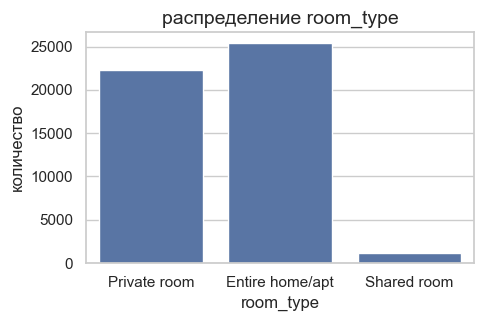

In [87]:
plt.figure(figsize=(5, 3))
sns.countplot(data=airbnb_dirty, x="room_type")

plt.title("распределение room_type", fontsize=14)
plt.xlabel("room_type", fontsize=12)
plt.ylabel("количество", fontsize=12)

plt.show()

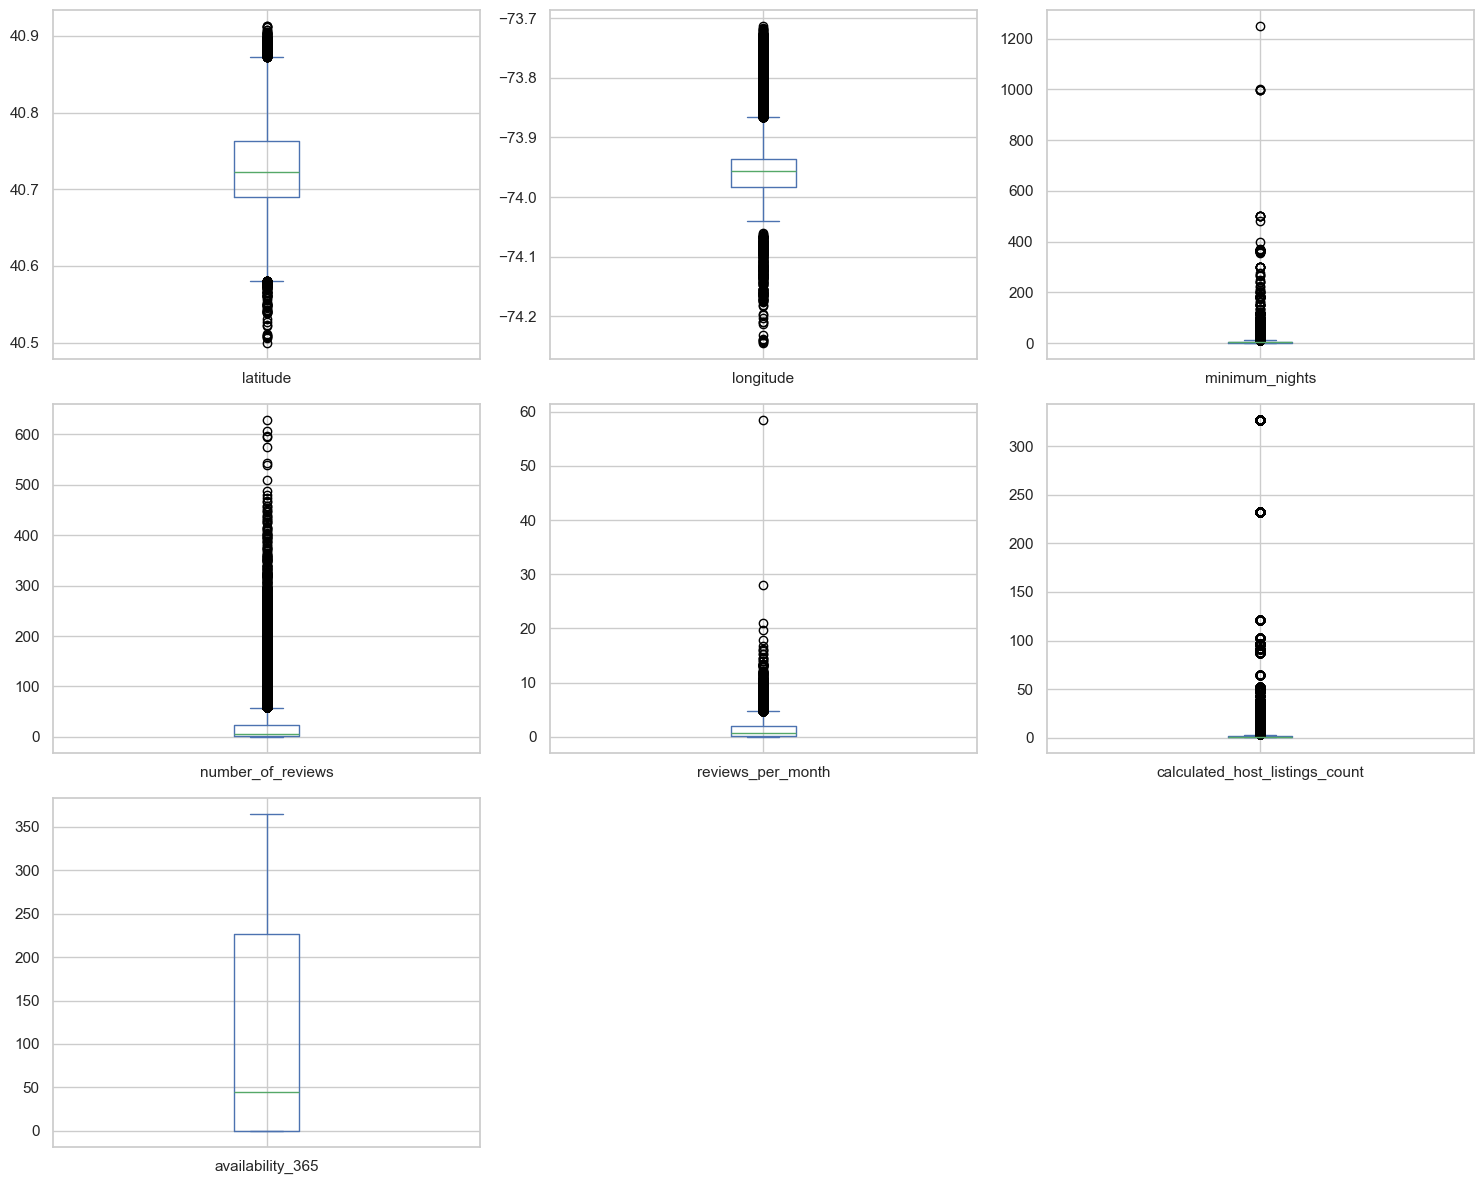

In [88]:
numeric_cols = airbnb_dirty.select_dtypes(include=["int64", "float64"]).drop(columns=["id", "host_id"])

numeric_cols.plot(
    kind="box", subplots=True, layout=(3, 3), figsize=(15, 12), sharey=False
)

plt.tight_layout()
plt.show()

### После EDA сформулируйте план чистки

Не пишите код сразу. Сначала словами:

- что сделаем с `price`;
- что сделаем с `name`;
- что сделаем с пропусками;
- что сделаем с экстремальными `minimum_nights`;
- какие новые признаки можно извлечь.

In [89]:
airbnb_dirty[airbnb_dirty["id"] == 28958489] # в экселе нашел непонятные символы, решил проверить, оказалось, что это русские символы

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
36409,28958489,Cosy room on the ocean beach.,93315723,Анита,Brooklyn,Brighton Beach,40.57795,-73.9616,Private room,50,2,27,2019-06-26,3.18,1,71


In [90]:
cleaning_plan = {
    "price": "Нужно написать regex, который бы убирал usd, $ и применял strip на строку price",
    "name": "привести к нижнему регистру, оставить только английский алфавит и знаки препинания",
    "missing_values": "last_review заполняем never, reviews_per_month = 0 там, где last_review nan(мало ли где-то ошибка и last_review имеет какое-то значение, а reviews_per_month - нет), host_name(оказалось, там есть и русские имена) лучше поставить просто пустую строку, для надёжности приведём к нижнему регистру",
    "outliers": "заполнить выбросы minimum_nights значениями 365",
    "new_features": [
        "no_reviews/few_reviews",
        "one-hot encoding для room_type",
        "one-hot encoding для neighbour_group"
    ],
}

cleaning_plan

{'price': 'Нужно написать regex, который бы убирал usd, $ и применял strip на строку price',
 'name': 'привести к нижнему регистру, оставить только английский алфавит и знаки препинания',
 'missing_values': 'last_review заполняем never, reviews_per_month = 0 там, где last_review nan(мало ли где-то ошибка и last_review имеет какое-то значение, а reviews_per_month - нет), host_name(оказалось, там есть и русские имена) лучше поставить просто пустую строку, для надёжности приведём к нижнему регистру',
 'outliers': 'заполнить выбросы minimum_nights значениями 365',
 'new_features': ['no_reviews/few_reviews',
  'one-hot encoding для room_type',
  'one-hot encoding для neighbour_group']}

In [91]:
# TODO 4. Очистите данные.
# Идеи, которые можно использовать:
# 1. price -> превратить в float
# 2. name -> заполнить пропуски пустой строкой
# 3. reviews_per_month -> заполнить нулями
# 4. last_review_missing -> бинарный признак пропуска
# 5. minimum_nights_clipped -> ограничить сверху, например p99 или 45
# 6. minimum_nights_log -> взять log1p
# 7. name_len, caps_ratio, has_exclamation -> простые текстовые признаки
# 8. is_entire_home -> бинарная цель для логистической регрессии

# Заготовки функций, если хотите:
# def clean_price_series(series):
#     cleaned = series.astype(str).str.replace(r'[^0-9.]', '', regex=True)
#     cleaned = cleaned.replace('', np.nan)
#     return pd.to_numeric(cleaned, errors='coerce')
#
# def caps_ratio(text):
#     letters = [ch for ch in str(text) if ch.isalpha()]
#     if not letters:
#         return 0.0
#     return sum(ch.isupper() for ch in letters) / len(letters)

airbnb_imp = airbnb_dirty.copy()

In [92]:
airbnb_imp["price"] = (airbnb_imp["price"]
                       .astype(str)
                       .str.lower()
                       .str.replace('$', '')
                       .str.replace('usd', '')
                       .str.replace(',', '')
                       .str.strip()
                       .astype(float))
# убираем $ usd и запятые, означающие тысячи

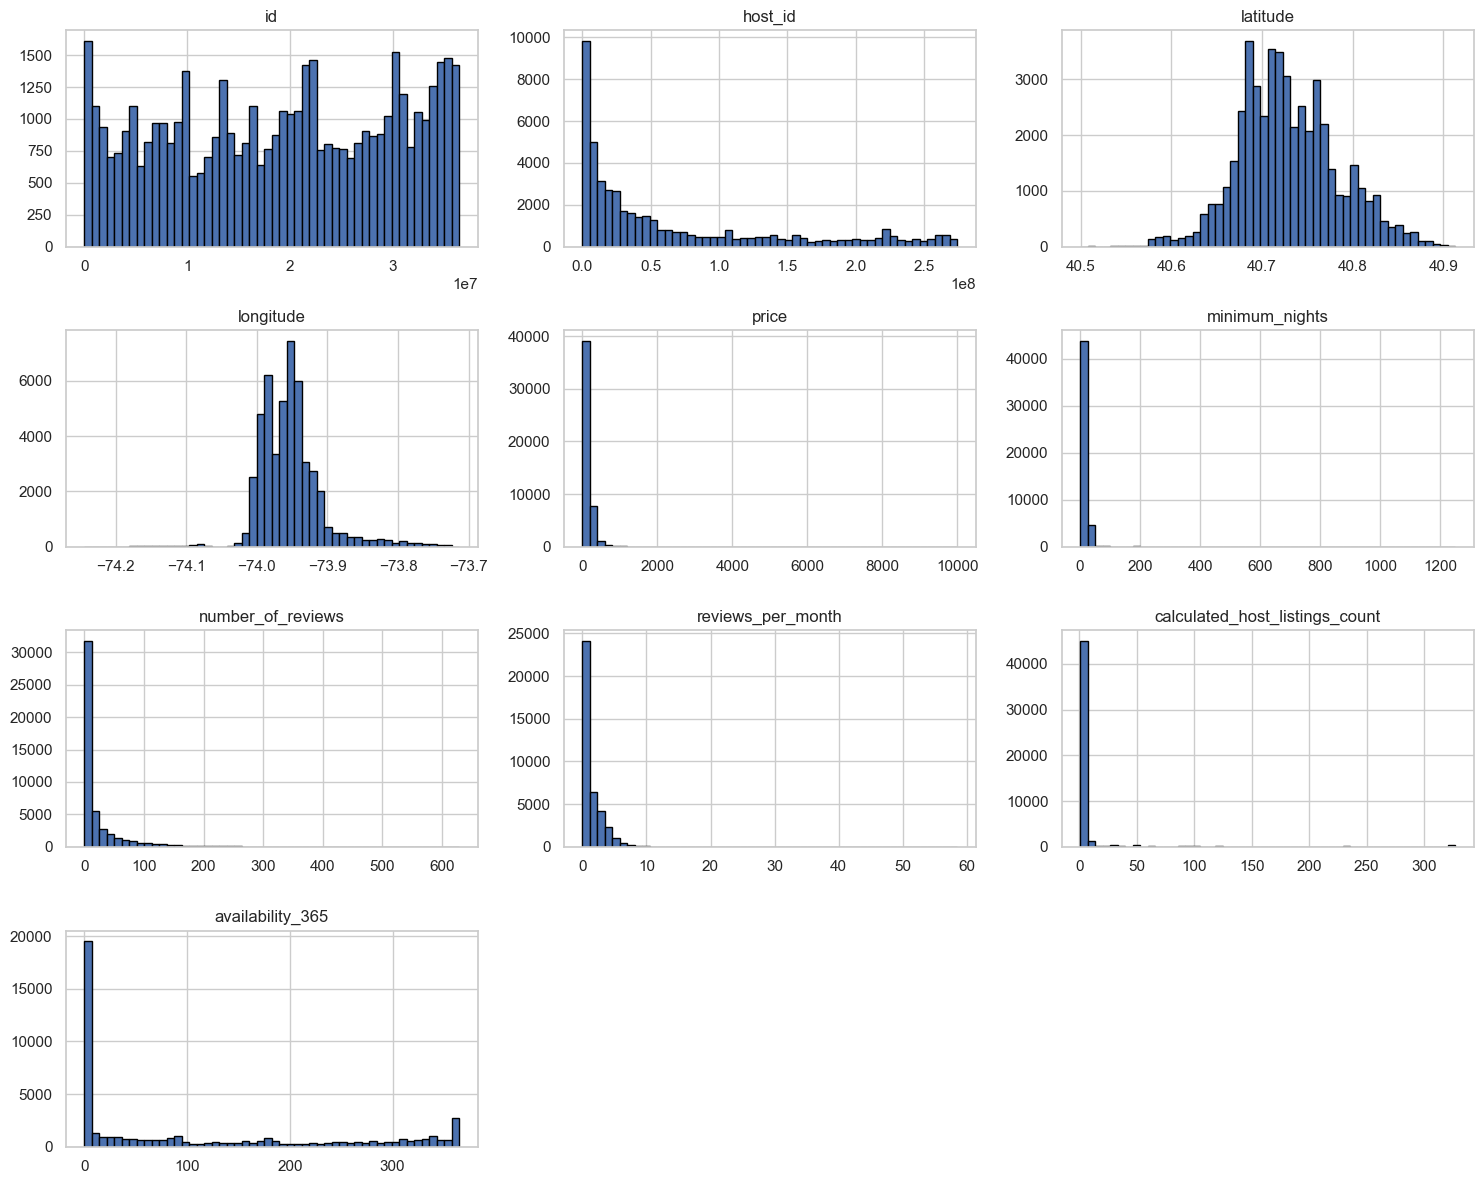

In [93]:
airbnb_imp.hist(figsize=(15, 12), bins=50, edgecolor="black")

plt.tight_layout()
plt.show()

In [94]:
# заполняем пропуски host_name
airbnb_imp["host_name"] = airbnb_imp["host_name"].fillna("").astype(str).str.lower()

# на середине feature engineering понял, что в этом нет необходимости, попытался вытянуть признаки из него, но ничего дельного не вышло
# чистим отзывы от мусора, приводим к приятному виду
pattern_for_name = r"[^a-zа-я0-9\s\.\,\!\?\;\:\(\)\'\"\-\|]"
airbnb_imp["name"] = (airbnb_imp["name"]
                      .astype(str)
                      .str.lower()
                      .str.replace(pattern_for_name, '', regex=True)
                      .str.strip())


# проверка вдруг где-то не совпадают пропущенные last_review и reviews_per_month
last_review_nan_equals_reviews_per_month_nan = airbnb_imp["last_review"][airbnb_imp["reviews_per_month"].isna()]
# 10052 - число пропусков
if len(last_review_nan_equals_reviews_per_month_nan) == len(airbnb_imp[airbnb_imp["last_review"].isna()]) == len(airbnb_imp[airbnb_imp["reviews_per_month"].isna()]):
    print("hell yeah")
    airbnb_imp["last_review"] = airbnb_imp["last_review"].fillna("never")
    airbnb_imp["reviews_per_month"] = airbnb_imp["reviews_per_month"].fillna(0)

# то, что в minimum_nights больше 365, станет 365
airbnb_imp["minimum_nights"] = airbnb_imp["minimum_nights"].clip(upper=365)

hell yeah


In [95]:
# проверка на пропуски
missing = airbnb_imp.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [96]:
airbnb_imp[
    ["host_name", "name", "price", "minimum_nights", "last_review", "reviews_per_month"]
].sample(8, random_state=42)

,host_name,name,price,minimum_nights,last_review,reviews_per_month
879,jane,come and go as you please in bkln!,89.0,3,2019-01-02,0.71
44383,giancarlo,"spacious, sunny room in queensbrooklyn",30.0,21,never,0.00
15394,alejandro,private bedroom in high-ceiling 4br apartment!,120.0,2,2017-04-28,0.43
43230,sonder (nyc),sonder | stock exchange | stunning 3br kitche...,470.0,2,2019-06-02,1.88
16332,gingie,spacious 2 bedroom with balcony!!!,199.0,2,2019-06-03,0.80
5966,amanda,entire 2br apt (not a railroad),170.0,1,2019-06-22,3.05
29838,hugo,1br in spacious 2 br in the heart of williamsb...,90.0,5,2018-02-21,0.06
41764,jing,comfortable place to live,60.0,30,never,0.00


## Блок 3. Линейная регрессия на Airbnb: цена

Теперь идем по той же логике, что и в основном ноуте.

### Что важно сделать честно

1. Сначала сравнить с `Mean baseline`.
2. Потом попробовать простую линейную регрессию.
3. Потом добавить feature engineering.
4. Если хочется углубиться, можно посчитать OLS руками через формулу из лекции.

In [97]:
# с учётом, что мы уже заполнили пропуски
regression_hypotheses = {
    "target": "price (обрежем после train_test_split)",
    "baseline_features": ["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"],
    "improved_features": ["one-hot endoding для neighbourhood_group", "one-hot endoding для room_type", "calculated_host_listings_count", "last_review"],
    "which_metric_is_most_important": "MAE, потому что у неё нет супер большой чувствительности к выбросам (которых тут ну очень много, и даже если их сделать меньше, всё равно скорее всего останутся большие значения). Если после радиклаьной чистки я буду уверен, что в данных нет сильных выбросов, я буду использовать RMSE, потому что она более жёсткая и точная",
}

regression_hypotheses

{'target': 'price (обрежем после train_test_split)',
 'baseline_features': ['latitude',
  'longitude',
  'minimum_nights',
  'number_of_reviews',
  'reviews_per_month',
  'calculated_host_listings_count',
  'availability_365'],
 'improved_features': ['one-hot endoding для neighbourhood_group',
  'one-hot endoding для room_type',
  'calculated_host_listings_count',
  'last_review'],
 'which_metric_is_most_important': 'MAE, потому что у неё нет супер большой чувствительности к выбросам (которых тут ну очень много, и даже если их сделать меньше, всё равно скорее всего останутся большие значения). Если после радиклаьной чистки я буду уверен, что в данных нет сильных выбросов, я буду использовать RMSE, потому что она более жёсткая и точная'}

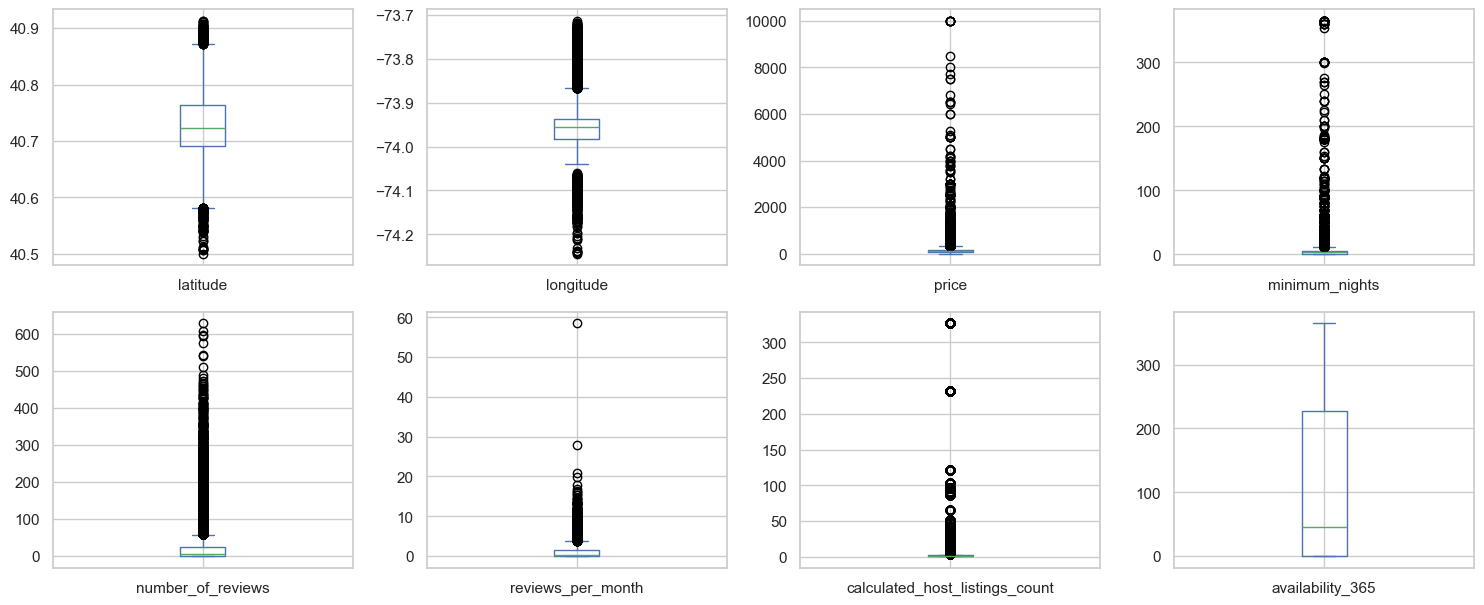

In [98]:
numeric_cols = airbnb_imp.select_dtypes(include=["int64", "float64"]).drop(columns=["id", "host_id"])

numeric_cols.plot(
    kind="box", subplots=True, layout=(4, 4), figsize=(15, 12), sharey=False
)

plt.tight_layout()
plt.show()

In [99]:
airbnb_imp["price_log"] = np.log1p(airbnb_imp["price"])
airbnb_imp = airbnb_imp.drop("price", axis=1)

In [100]:
airbnb_imp.describe()

,id,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,6.942980,23.274466,1.090910,7.143982,112.781327,4.736885
std,1.098311e+07,7.861097e+07,0.054530,0.046157,17.530294,44.550582,1.597283,32.952519,131.622289,0.695344
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,1.000000,1.000000,0.040000,1.000000,0.000000,4.248495
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,3.000000,5.000000,0.370000,1.000000,45.000000,4.672829
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,5.000000,24.000000,1.580000,2.000000,227.000000,5.170484
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,365.000000,629.000000,58.500000,327.000000,365.000000,9.210440


In [101]:
airbnb_imp[airbnb_imp["calculated_host_listings_count"] > 200]
# есть выбросы в calculated_host_listings_count. несмотря на количество объявлений, большая часть из них не имеет отзывов, поэтому можно удалить объявления без отзывов (логично, что если нет отзывов, значит туда либо никто не ездит из-за цены/качества, либо просто потмоу что цена абсурдно большая)
airbnb_imp = airbnb_imp[(airbnb_imp["last_review"] != "never") | (airbnb_imp["calculated_host_listings_count"] <= 200)]
airbnb_imp[(airbnb_imp["last_review"] != "never")].sort_values(by='last_review', ascending=False)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_log
48852,36455809,"cozy private room in bushwick, brooklyn!!!",74162901,christine,Brooklyn,Bushwick,40.69805,-73.92801,Private room,1,1,2019-07-08,1.00,1,1,3.433987
42665,33119863,queens studio.,42540127,tio,Queens,Bayside,40.77067,-73.78278,Entire home/apt,2,37,2019-07-08,10.37,1,6,4.025352
44459,34244391,a space like a home,258536261,judy,Brooklyn,Cypress Hills,40.67959,-73.88302,Entire home/apt,2,11,2019-07-08,5.69,1,179,4.615121
44446,34231172,fully renovated brick house floor in brooklyn,59642348,kevin,Brooklyn,Sunset Park,40.64550,-74.01262,Entire home/apt,1,9,2019-07-08,9.00,1,106,4.564348
44382,34204893,gorgeous spacious 1 bedroom apartment!!!,85773188,mark,Brooklyn,Brighton Beach,40.57589,-73.96636,Entire home/apt,1,10,2019-07-08,9.09,1,20,4.465908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,32363,fully furnished basement apartment,140025,fredah,Queens,Flushing,40.74028,-73.83168,Private room,2,1,2011-09-19,0.01,1,1,4.948760
125,28396,modern apt with spectacular views,6197784,jo,Brooklyn,Williamsburg,40.71923,-73.96468,Private room,1,9,2011-09-18,0.08,1,245,4.510860
330,81739,loft w terrace box house hotel!!!,417504,the box house hotel,Brooklyn,Greenpoint,40.73842,-73.95312,Private room,3,2,2011-05-12,0.02,28,60,5.521461
163,40039,luxurious condo in dubmo with view,171851,henry,Brooklyn,DUMBO,40.70207,-73.98571,Private room,3,14,2011-04-25,0.13,1,189,5.525453


In [102]:
airbnb_imp[airbnb_imp['reviews_per_month'] > 50]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_log
42075,32678719,enjoy great views of the city in our deluxe room!,244361589,row nyc,Manhattan,Theater District,40.75918,-73.98801,Private room,1,156,2019-07-07,58.5,9,299,4.615121


In [103]:
# заметил, что есть значения с availability_365==0. обнаружил, что это почти половина датасета, а там, где нет отзывов - 4845 строк, что очень много (10 процентов). не буду трогать
airbnb_imp[(airbnb_imp["availability_365"] == 0) & (airbnb_imp["last_review"] == 'never')]
# airbnb_imp = airbnb_imp[(airbnb_imp["availability_365"] != 0) | (airbnb_imp["last_review"] != 'never')]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_log
26,8700,magnifique suite au n de manhattan - vue cloitres,26394,claude & sophie,Manhattan,Inwood,40.86754,-73.92639,Private room,4,0,never,0.0,1,0,4.394449
193,51438,1 bedroom in 2 bdrm apt- upper east,236421,jessica,Manhattan,Upper East Side,40.77333,-73.95199,Private room,14,0,never,0.0,2,0,4.875197
267,64015,prime east village 1 bedroom,146944,david,Manhattan,East Village,40.72807,-73.98594,Entire home/apt,3,0,never,0.0,1,0,5.303305
276,65556,"room in s3rdbedford, williamsburg!!!",320422,marlon,Brooklyn,Williamsburg,40.71368,-73.96260,Private room,3,0,never,0.0,1,0,4.110874
390,118680,spacious east village apt near it all!!!,599354,bobby,Manhattan,East Village,40.73067,-73.98702,Private room,2,0,never,0.0,1,0,4.477337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48550,36313048,sunny room with private entrance in shared home,16883913,tiffany,Queens,Ridgewood,40.69919,-73.89902,Private room,1,0,never,0.0,1,0,3.828641
48731,36410519,sunlight charming apt. in the heart of brooklyn,121384174,luciana paula,Brooklyn,Park Slope,40.66716,-73.98101,Entire home/apt,8,0,never,0.0,1,0,4.718499
48756,36419441,murray hill masterpiece!!!,273824202,david,Manhattan,Murray Hill,40.74404,-73.97239,Entire home/apt,2,0,never,0.0,1,0,4.867534
48760,36420725,"sunnyside, queens 15 mins to midtown clean comfy",19990280,brandon,Queens,Sunnyside,40.74719,-73.91919,Private room,1,0,never,0.0,1,0,3.850148


In [104]:
# сделал one-hot encoding здесь, потому что модель не обрабатывает строки
airbnb_imp = pd.get_dummies(
    airbnb_imp,
    columns=["neighbourhood_group"],
    drop_first=True,  # если оставить первый столбец, линейной регрессии будет грустненько, потому что она будет думать, что строчки one-hot encoding зависимы друг от друга
    dtype=int,  # чтобы получились числа 0 и 1, а не були
)
airbnb_imp = pd.get_dummies(
    airbnb_imp,
    columns=["room_type"],
    drop_first=True,
    dtype=int,
)

In [105]:
# TODO 5. Сделайте baseline для регрессии.
# План:
# 1. выбрать target, например price_capped
# 2. сделать train/test split
# 3. сравнить Mean baseline и sklearn LinearRegression
# 4. посчитать R2, MAE, RMSE, NRMSE, MAPE_%

# Подсказка:
# y_mean_pred = np.repeat(y_train.mean(), len(y_test))
# regression_metrics(y_test, y_mean_pred)
# regression_metrics(y_test, model.predict(X_test))


target = 'price_log'
cols_to_drop = [target, 'id', 'name', 'host_id', 'host_name', 'last_review', 'neighbourhood']
X = airbnb_imp.drop(columns=cols_to_drop)
y = airbnb_imp[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# mean baseline
y_mean_pred = np.repeat(y_train.mean(), len(y_test))
print('mean baseline:', regression_metrics(y_test, y_mean_pred))

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('LinearRegression:', regression_metrics(y_test, model.predict(X_test)))
print("MAE exp: ", mae_manual(np.expm1(y_test), np.expm1(y_pred)))
# 60.60797483004566

mean baseline: {'R2': np.float64(-7.364496930950537e-05), 'MAE': np.float64(0.546357525257602), 'RMSE': np.float64(0.6911861239180692), 'NRMSE': np.float64(1.000036821806732), 'MAPE_%': np.float64(11.75533435792907)}
LinearRegression: {'R2': np.float64(0.48523107744644445), 'MAE': np.float64(0.3591649171298073), 'RMSE': np.float64(0.4958898047842168), 'NRMSE': np.float64(0.717473987370661), 'MAPE_%': np.float64(7.558532663874982)}
MAE exp:  60.60797483004566


In [106]:
# TODO 6. Добавьте feature engineering и сравните качество.
# Идеи признаков:
# - neighbourhood_group
# - room_type
# - latitude, longitude
# - minimum_nights_clipped, minimum_nights_log
# - name_len, caps_ratio, has_exclamation
# - last_review_missing

# Подсказка:
# X_improved = pd.get_dummies(..., drop_first=True)


In [107]:
airbnb_imp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48571 entries, 0 to 48894
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 48571 non-null  int64  
 1   name                               48571 non-null  object 
 2   host_id                            48571 non-null  int64  
 3   host_name                          48571 non-null  object 
 4   neighbourhood                      48571 non-null  object 
 5   latitude                           48571 non-null  float64
 6   longitude                          48571 non-null  float64
 7   minimum_nights                     48571 non-null  int64  
 8   number_of_reviews                  48571 non-null  int64  
 9   last_review                        48571 non-null  object 
 10  reviews_per_month                  48571 non-null  float64
 11  calculated_host_listings_count     48571 non-null  int64  


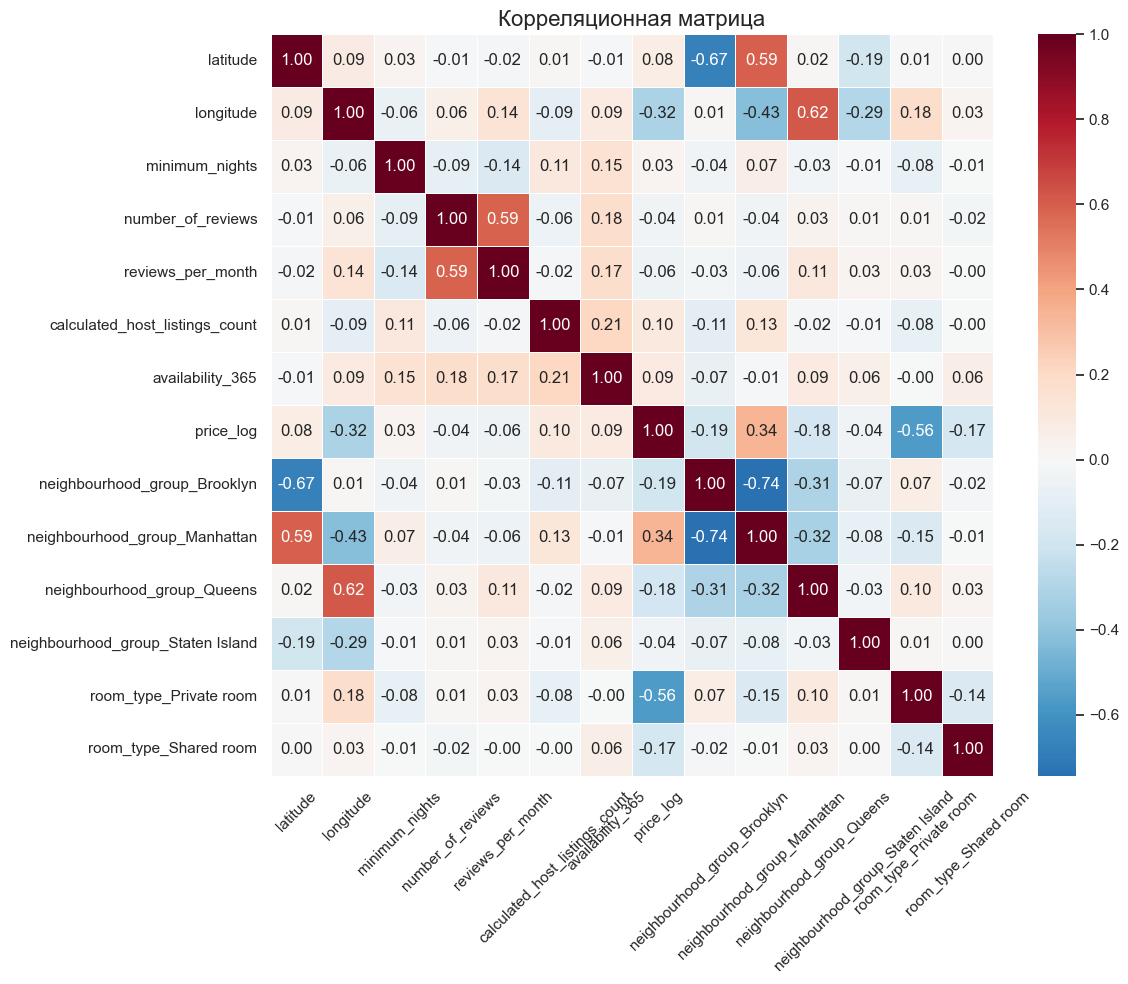

In [108]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    airbnb_imp.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review', 'neighbourhood']).corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Корреляционная матрица', fontsize=16)
plt.xticks(rotation=45) # поворот подписей 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

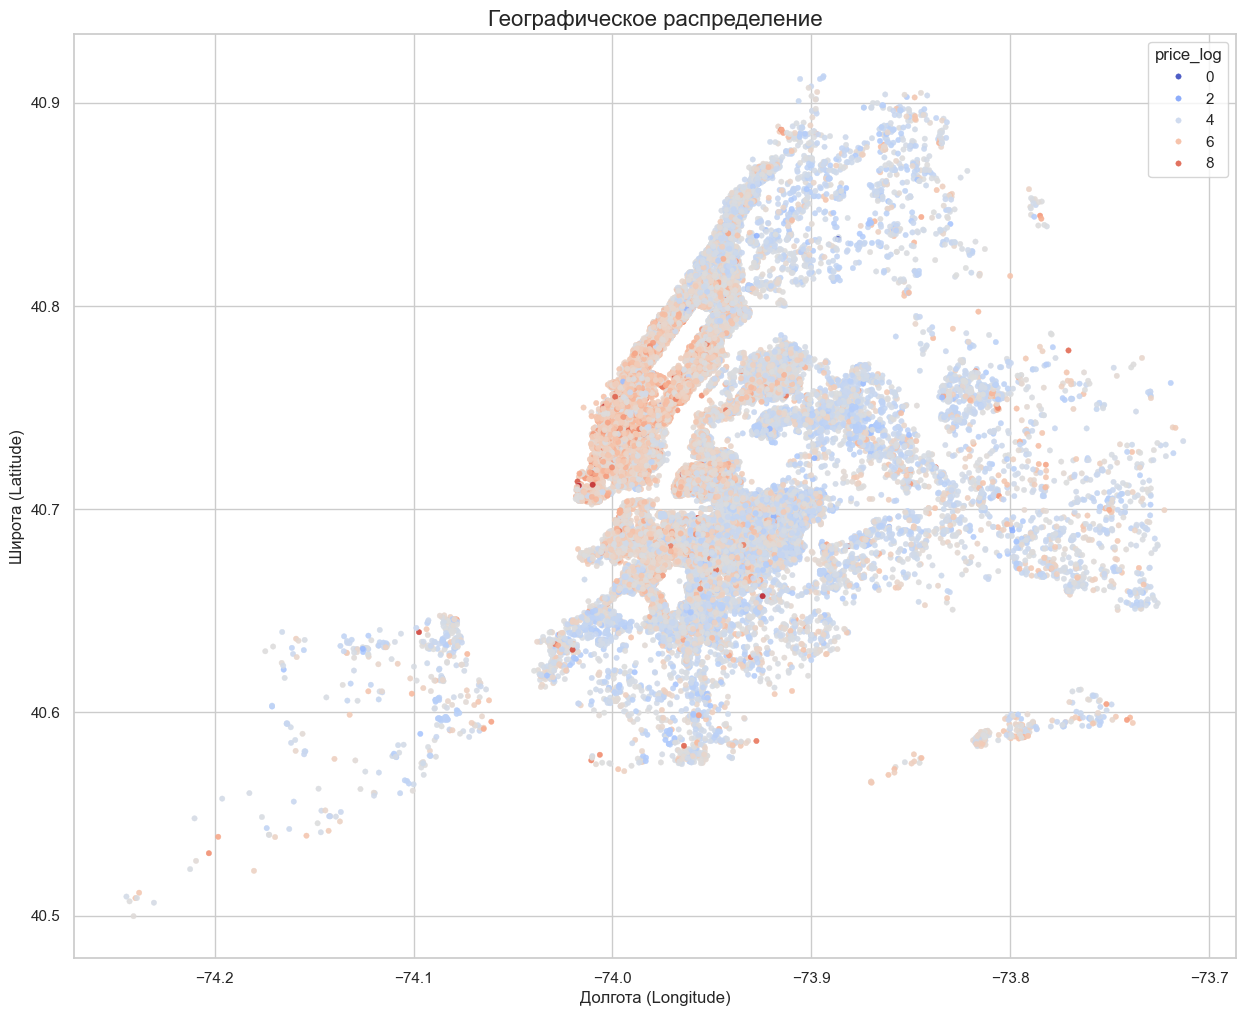

In [109]:
plt.figure(figsize=(15, 12))

sns.scatterplot(
    data=airbnb_imp, 
    x='longitude', 
    y='latitude', 
    hue='price_log', # раскрашиваем по столбцу с ценой
    palette='coolwarm',
    alpha=0.9, 
    s=15,
    edgecolor=None
)

plt.title('Географическое распределение', fontsize=16)
plt.xlabel('Долгота (Longitude)')
plt.ylabel('Широта (Latitude)')
plt.show()

In [110]:
# самый дорогой район - около Эмпайр-стейт-билдинг. сделаем его "центром притяжения" и будем измерять расстояние до него, потому что по графику видно, что чем ближе к нему, тем больше цена. используем не просто теорему пифагора, а формулу гаверсинуса, которая вычисляет точное расстояние
ESB_latitude = 40.7476406
ESB_longitude = -74.0097132
# airbnb_imp["distance_to_ESB"] = ((ESB_longitude - airbnb_imp['longitude']) ** 2 + (ESB_latitude - airbnb_imp['latitude']) ** 2) ** 0.5

lat1, lon1 = np.radians(ESB_latitude), np.radians(ESB_longitude)
lat2, lon2 = np.radians(airbnb_imp["latitude"]), np.radians(airbnb_imp["longitude"])

dlon = lon2 - lon1
dlat = lat2 - lat1

# применяем формулу гаверсинуса
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
c = 2 * np.arcsin(np.sqrt(a))

earth_radius = 6371

airbnb_imp["distance_to_ESB_km"] = c * earth_radius

# airbnb_imp = airbnb_imp.drop(columns=['longitude', 'latitude'])

In [111]:
X_imp = airbnb_imp.drop(columns=cols_to_drop)
y_imp = airbnb_imp[target]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imp, y_imp, test_size=0.3, random_state=42
)

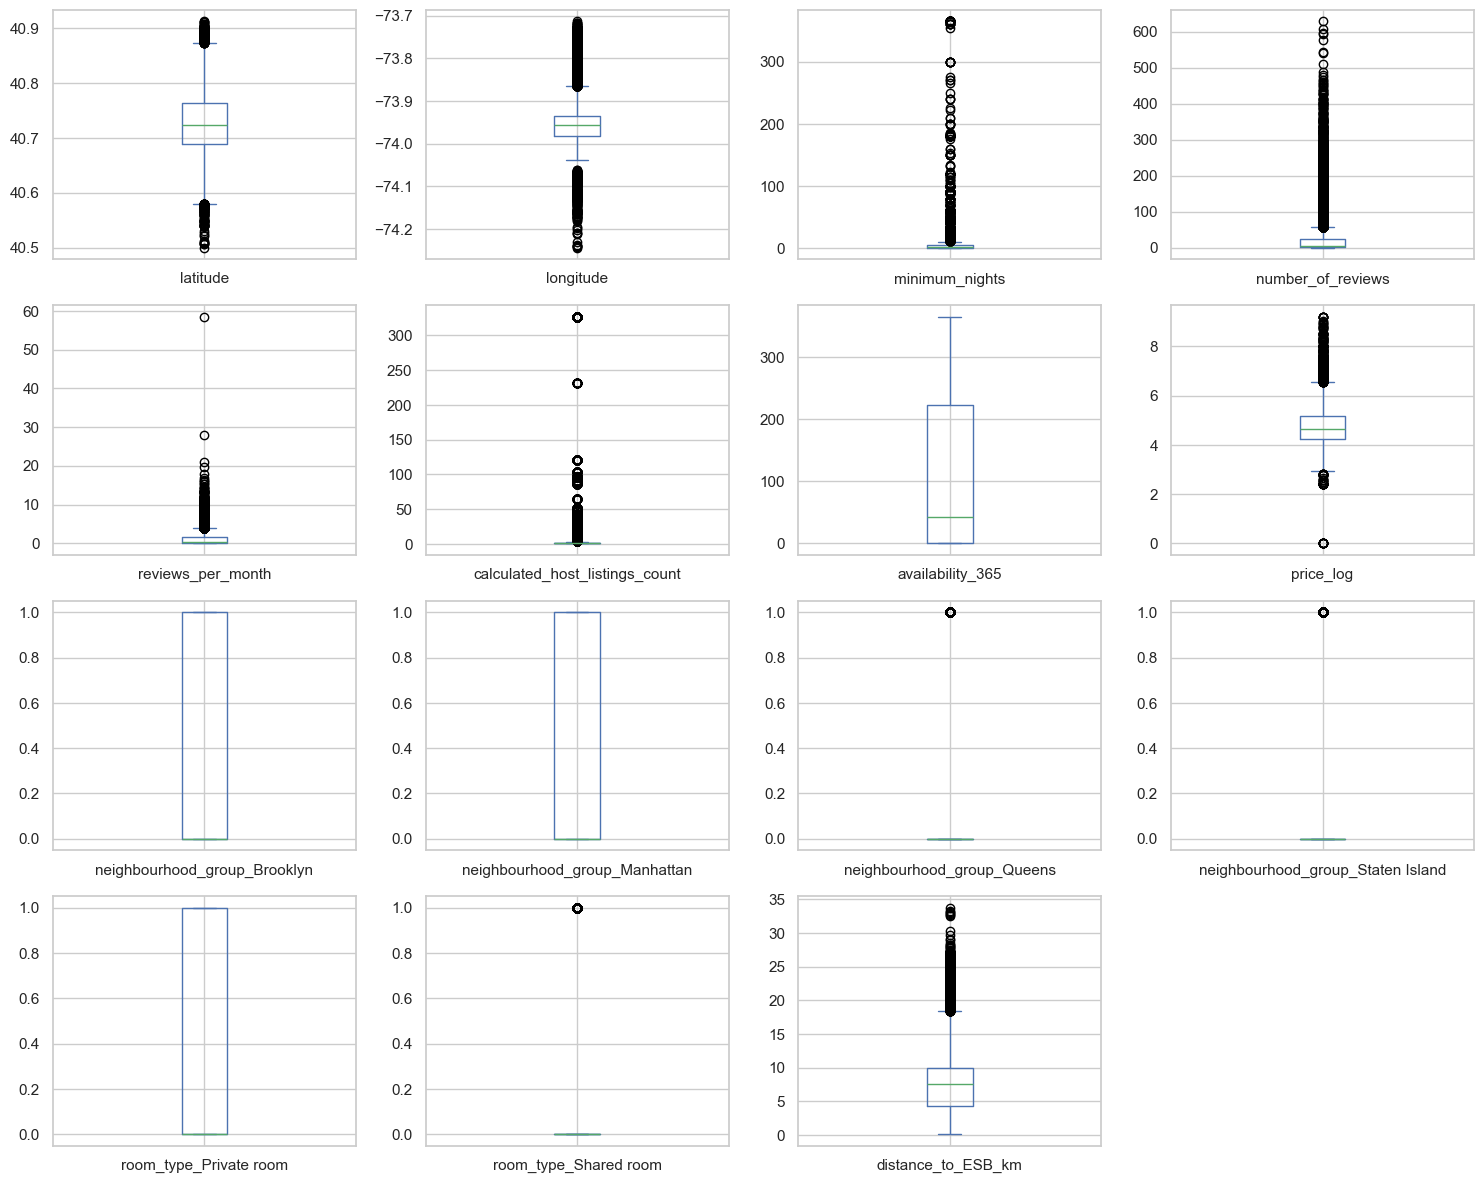

In [112]:
numeric_cols = airbnb_imp.select_dtypes(include=["int64", "float64"]).drop(columns=["id", "host_id"])

numeric_cols.plot(
    kind="box", subplots=True, layout=(4, 4), figsize=(15, 12), sharey=False
)

plt.tight_layout()
plt.show()

In [ ]:
upper_price_limit = y_train_imp.quantile(0.99)
y_train_imp = y_train_imp.clip(upper=upper_price_limit)
y_test_imp = y_test_imp.clip(upper=upper_price_limit)

upper_number_of_reviews_limit = X_train_imp['number_of_reviews'].quantile(0.99)
X_train_imp['number_of_reviews'] = X_train_imp['number_of_reviews'].clip(upper=upper_number_of_reviews_limit)
X_test_imp['number_of_reviews'] = X_test_imp['number_of_reviews'].clip(upper=upper_number_of_reviews_limit)

mean_number_of_reviews = np.mean(X_train_imp['number_of_reviews'])
X_train_imp['many_reviews'] = (X_train_imp['number_of_reviews'] > mean_number_of_reviews).astype(int)
X_test_imp['many_reviews'] = (X_test_imp['number_of_reviews'] > mean_number_of_reviews).astype(int)

mean_number_of_reviews = np.mean(X_train_imp['calculated_host_listings_count'])
X_train_imp['popular_host'] = (X_train_imp['calculated_host_listings_count'] > mean_number_of_reviews).astype(int)
X_test_imp['popular_host'] = (X_test_imp['calculated_host_listings_count'] > mean_number_of_reviews).astype(int)


In [114]:
# TODO 7. Если хотите пойти глубже, реализуйте ручной OLS.
# Это прямое продолжение формулы из лекции:
# w* = (X^T X)^(-1) X^T y
#
# Подсказка:
# weights = manual_linear_weights(X_train, y_train)
# y_pred_manual = manual_linear_predict(X_test, weights)
# regression_metrics(y_test, y_pred_manual)
#
# Важно:
# - перед этим X должен быть только числовой
# - лучше сравнить ручной результат со sklearn на одной и той же матрице признаков

# Ваш код здесь

In [ ]:
model = LinearRegression()
model.fit(X_train_imp, y_train_imp)

y_pred_imp = model.predict(X_test_imp)
print('LinearRegression:', regression_metrics(y_test_imp, model.predict(X_test_imp)))
print("MAE exp: ", mae_manual(np.expm1(y_test_imp), np.expm1(y_pred_imp)))
# 52.18719406513988

LinearRegression: {'R2': np.float64(0.5244044260120053), 'MAE': np.float64(0.3430545699630476), 'RMSE': np.float64(0.4652144712977896), 'NRMSE': np.float64(0.689634377034668), 'MAPE_%': np.float64(7.243078813765965)}
MAE exp:  52.18719406513988


### Вопросы после регрессии

- Почему `R2` может быть скромным, а модель всё равно полезнее mean baseline?
- Чем `MAE` отличается от `RMSE` по смыслу?
- Почему `RMSE` особенно чувствительна к редким большим ошибкам?
- Почему на Airbnb вообще не стоит ждать идеально высокой линейной метрики?

In [116]:
# итого получилось снизить MAE с 61 доллара до 52, что весьма неплохой результат

In [117]:
# 1. R2 показывает, какую долю разброса цен смогла объяснить модель. даже если он скромный, это означает, что модель нашла закономерности, которые лучше случайности. с точки зрения принятия решений эта модель уже приносит реальную пользу, в отличие от mean baseline, так как улавливает главный тренд (пока mean везде влепит 150 долларов, наша модель подумает и решит, что в одном месте будет 40, а в другом - 450)
# 2. MAE отвечает на вопрос: "на сколько долларов в среднем мы ошибаемся?", относится ко всем ошибкам равноценно. RMSE - метрика "катастрофичности", которая сильно снижается при больших ошибках.ииспользуется тогда, когда несколько мелких ошибок - это нормально, а одна огромная - это провал.
# 3. перед тем как усреднить значения и брать корень, каждая из ошибок возводится в квадрат, из-за чего сильно увеличиваются значения (например, при 10 ошибках в 5 долларов сумма квадратов ошибок будет всего 250, а при 1 ошибке в 50 будет 2500, что в 10 раз больше, хотя это всего одна ошибка)
# 4. ценообразование - сложная вещь (не опираясь на датасет). например, за наличие бассейна в Манхэттене будет наценка 40%, а в Staten Island - 5%, потому что сам район больше промышленнный, и в нём больше рек. 

## Блок 4. Классификация на Airbnb: тип жилья

Теперь меняем задачу.

### Бинарная цель

- `1` = `Entire home/apt`
- `0` = `Private room`

### Что важно сделать

1. Сравнить с majority baseline.
2. Проверить `LinearRegression + clip` как плохой классификатор.
3. Обучить `LogisticRegression`.
4. Если хочется углубиться, сделать ручную логистическую регрессию через сигмоиду.

In [118]:
classification_hypotheses = {
    "target": "is_entire_home",
    "useful_features": ["price_log", "distance_to_ESB_km", "minimum_nights", "number_of_reviews"],
    "why_logistic_is_more_natural": "линейная регрессия будет пытаться 'усреднить' значения, чтобы минимизировать ошибку. логистическая регрессия использует сигмоиду, которая плавно 'сжимает' любые ответы модели в диапазон от 0 до 1, превращая их в вероятности",
    "which_metric_is_most_important": "думаю, хорошо подойдёт roc_auc и f1",
}

classification_hypotheses

{'target': 'is_entire_home',
 'useful_features': ['price_log',
  'distance_to_ESB_km',
  'minimum_nights',
  'number_of_reviews'],
 'why_logistic_is_more_natural': "линейная регрессия будет пытаться 'усреднить' значения, чтобы минимизировать ошибку. логистическая регрессия использует сигмоиду, которая плавно 'сжимает' любые ответы модели в диапазон от 0 до 1, превращая их в вероятности",
 'which_metric_is_most_important': 'думаю, хорошо подойдёт roc_auc и f1'}

In [119]:
# TODO 8. Сделайте baseline для классификации.
# Шаги:
# 1. оставьте только Entire home/apt и Private room
# 2. соберите признаки
# 3. сделайте majority baseline
# 4. посчитайте Accuracy, Precision, Recall, F1, ROC_AUC, LogLoss

# Подсказка:
# majority_class = int(y_train.mean() >= 0.5)
# majority_prob = np.repeat(float(y_train.mean()), len(y_test))
# majority_pred = np.repeat(majority_class, len(y_test))
# classification_metrics(y_test, majority_prob, majority_pred)

airbnb_cls = airbnb_dirty[airbnb_dirty['room_type'].isin(['Entire home/apt', 'Private room'])].copy()

# создаем бинарный таргет: 1 = Entire home/apt, 0 = Private room
airbnb_cls['is_entire_home'] = (airbnb_cls['room_type'] == 'Entire home/apt').astype(int)
X_cls = airbnb_cls.drop(columns=[col for col in cols_to_drop if col in airbnb_cls.columns])
y_cls = airbnb_cls['is_entire_home']

X_cls = pd.get_dummies(X_cls, drop_first=True, dtype=int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=42
)

majority_class = int(y_train_c.mean() >= 0.5)

majority_prob = np.repeat(float(y_train_c.mean()), len(y_test_c))
majority_pred = np.repeat(majority_class, len(y_test_c))

print(classification_metrics(y_test_c, majority_prob, majority_pred))

print('roc_auc:', roc_auc_score(y_test_c, majority_pred))
print('f1:', f1_manual(y_test_c, majority_pred))

{'Accuracy': np.float64(0.5283150617973605), 'Precision': np.float64(0.5283150617973605), 'Recall': np.float64(1.0), 'F1': np.float64(0.6913693059807191), 'ROC_AUC': 0.5, 'LogLoss': np.float64(0.6916076901205648)}
roc_auc: 0.5
f1: 0.6913693059807191


In [ ]:
# TODO 9. Сравните LinearRegression + clip и LogisticRegression.
# Подсказка:
# 1. для LinearRegression получите сырые scores
# 2. потом prob = np.clip(scores, 0, 1)
# 3. pred = (prob >= 0.5).astype(int)
# 4. для LogisticRegression используйте predict_proba
# 5. сравните метрики не только между собой, но и с majority baseline

lin_cls_model = LinearRegression()
lin_cls_model.fit(X_train_c, y_train_c)

lin_scores = lin_cls_model.predict(X_test_c)

# обрезаем значения, чтобы имитировать вероятность
lin_prob = np.clip(lin_scores, 0, 1)

# превращаем вероятности в классы по порогу 0.5
lin_pred = (lin_prob >= 0.5).astype(int)

print("\\n LinearRegression + clip")
print(classification_metrics(y_test_c, lin_prob, lin_pred))

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# TODO 10. Если хотите пойти глубже, реализуйте ручную логистическую регрессию.
# Это прямое продолжение лекции:
# p(x) = sigmoid(w^T x)
# log-loss = -mean(y log p + (1-y) log(1-p))
#
# Подсказка:
# 1. возьмите маленький набор числовых признаков
# 2. стандартизируйте train/test
# 3. weights, history = fit_logistic_manual(X_train_std, y_train, lr=0.2, steps=1200)
# 4. prob = predict_logistic_manual(X_test_std, weights)
# 5. pred = (prob >= 0.5).astype(int)
# 6. classification_metrics(y_test, prob, pred)

# Ваш код здесь

### Вопросы после классификации

- Почему `Accuracy` не всегда достаточно?
- Когда важнее `Precision`, а когда `Recall`?
- Почему `LogLoss` может быть содержательнее, чем просто доля угаданных классов?
- Если `LinearRegression + clip` не сильно хуже по `Accuracy`, почему мы всё равно говорим, что логистическая регрессия здесь естественнее?

## Блок 5. Свои идеи

Теперь можно предлагать собственные улучшения.

Хорошие направления:

- взять `log(price)` вместо `price_capped`;
- попробовать новые текстовые признаки;
- сильнее ограничить выбросы;
- оставить только крупные районы;
- попробовать другие наборы признаков для ручной логистической регрессии;
- сравнивать новые идеи не только с лучшей моделью, но и с baseline.

In [ ]:
student_experiment = {
    "idea": "",
    "why_it_should_help": "",
    "which_metric_should_improve": "",
    "result": "",
}

student_experiment

{'idea': '',
 'why_it_should_help': '',
 'which_metric_should_improve': '',
 'result': ''}

In [ ]:
# TODO 11. Песочница для вашей идеи.
# Совет:
# 1. сначала напишите гипотезу словами выше
# 2. потом укажите, по какой метрике ждете улучшение
# 3. только потом пишите код

# Ваш код здесь

## Финальная рефлексия

Заполните коротко, но честно. Это важнее, чем просто много кода.

In [ ]:
final_reflection = {
    "what_helped_in_eda_the_most": "",
    "which_regression_metric_was_most_informative": "",
    "which_classification_metric_was_most_informative": "",
    "where_linear_regression_was_natural": "",
    "why_logistic_regression_was_more_natural_for_binary_target": "",
    "which_formula_from_the_lecture_became_clearer_after_code": "",
}

final_reflection

{'what_helped_in_eda_the_most': '',
 'which_regression_metric_was_most_informative': '',
 'which_classification_metric_was_most_informative': '',
 'where_linear_regression_was_natural': '',
 'why_logistic_regression_was_more_natural_for_binary_target': '',
 'which_formula_from_the_lecture_became_clearer_after_code': ''}